# Credit Risk Analysis and Loan Default Prediction

**Project Overview**

This project analyzes borrower and loan data to identify the key factors associated with loan default. The analysis includes data cleaning, exploratory data analysis (EDA), business insights, and a Logistic Regression model to predict whether a borrower is likely to default. The cleaned dataset is prepared for interactive visualization in Tableau.

**Project Objectives**
- Clean and prepare the dataset for analysis.
- Explore borrower characteristics and loan patterns.
- Identify factors associated with loan default.
- Build and evaluate a Logistic Regression model.
- Create a Tableau dashboard to present key business insights.

# Step 1: Import Required Libraries

Import the Python libraries required for data manipulation, data visualization, and machine learning throughout this project.


In [113]:
# Install required libraries (run this cell only once if needed)
%pip install pandas numpy matplotlib seaborn scikit-learn

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

# Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix)
from sklearn.metrics import roc_auc_score, roc_curve

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


# Step 2: Load the Dataset

The dataset is loaded into a pandas DataFrame for analysis.

In [114]:
df = pd.read_csv("credit_risk_dataset.csv")

# Step 3: Display the First Five Rows

Viewing the first five rows helps verify that the dataset has been loaded correctly and provides an initial understanding of the data structure.

In [115]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


# Step 4: Check the Dataset Shape

Determine the number of rows and columns in the dataset.

In [116]:
df.shape

(32581, 12)

# Step 5: Display the Column Names

View the names of all variables in the dataset.

In [117]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

# Step 6: Check the Dataset Information

Inspect the dataset to understand the data types, number of non-null values, and memory usage.

In [118]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 2.5+ MB


# Step 7: Generate Summary Statistics

Generate descriptive statistics to understand the distribution of the numerical variables in the dataset.

In [119]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,32581.0,27.734600,6.348078,20.00,23.00,26.00,30.00,144.00
person_income,32581.0,66074.848470,61983.119168,4000.00,38500.00,55000.00,79200.00,6000000.00
person_emp_length,31686.0,4.789686,4.142630,0.00,2.00,4.00,7.00,123.00
loan_amnt,32581.0,9589.371106,6322.086646,500.00,5000.00,8000.00,12200.00,35000.00
loan_int_rate,29465.0,11.011695,3.240459,5.42,7.90,10.99,13.47,23.22
loan_status,32581.0,0.218164,0.413006,0.00,0.00,0.00,0.00,1.00
loan_percent_income,32581.0,0.170203,0.106782,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32581.0,5.804211,4.055001,2.00,3.00,4.00,8.00,30.00


# Step 8: Check for Missing Values

Identify the number of missing values in each column before cleaning the dataset.

In [120]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

# Step 9: Handle Missing Values

Replace missing values in the numerical columns using the median to preserve the distribution of the data and reduce the impact of outliers.

In [121]:
df["person_emp_length"] = df["person_emp_length"].fillna(df["person_emp_length"].median())

df["loan_int_rate"] = df["loan_int_rate"].fillna(df["loan_int_rate"].median())

# Step 10: Verify Missing Values

Verify that all missing values have been successfully handled.

In [122]:
df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

# Step 11: Check for Duplicate Records

Check whether the dataset contains any duplicate records before proceeding with the analysis.

In [123]:
df.duplicated().sum()

np.int64(165)

# Step 12: Remove Duplicate Records

Remove duplicate records to ensure each observation is unique and to improve the quality of the dataset.

In [124]:
df = df.drop_duplicates()

# Step 13: Verify Duplicate Removal

Confirm that all duplicate rows have been successfully removed from the dataset.

In [125]:
df.duplicated().sum()

np.int64(0)

# Step 14: Check the Updated Dataset Shape

Display the updated dimensions of the dataset after removing duplicate rows.

In [126]:
df.shape

(32416, 12)

# Step 15: Inspect Numerical Variables

Review the distribution and range of numerical variables to identify potential outliers and unrealistic values.

In [127]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,32416.0,27.747008,6.354100,20.00,23.00,26.00,30.00,144.00
person_income,32416.0,66091.640826,62015.580269,4000.00,38542.00,55000.00,79218.00,6000000.00
person_emp_length,32416.0,4.768880,4.090411,0.00,2.00,4.00,7.00,123.00
loan_amnt,32416.0,9593.845632,6322.730241,500.00,5000.00,8000.00,12250.00,35000.00
loan_int_rate,32416.0,11.014662,3.083050,5.42,8.49,10.99,13.11,23.22
loan_status,32416.0,0.218688,0.413363,0.00,0.00,0.00,0.00,1.00
loan_percent_income,32416.0,0.170250,0.106812,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32416.0,5.811297,4.059030,2.00,3.00,4.00,8.00,30.00


# Step 16: Identify Unrealistic Values

Identify observations with unrealistic values that may represent data entry errors.

In [128]:
df[df["person_age"] > 100]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
81,144,250000,RENT,4.0,VENTURE,C,4800,13.57,0,0.02,N,3
183,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.86,0,0.03,N,2
575,123,80004,RENT,2.0,EDUCATION,B,20400,10.25,0,0.25,N,3
747,123,78000,RENT,7.0,VENTURE,B,20000,10.99,0,0.26,N,4
32297,144,6000000,MORTGAGE,12.0,PERSONAL,C,5000,12.73,0,0.00,N,25


# Step 17: Remove Unrealistic Age Values

Remove records containing unrealistic age values to improve the quality and reliability of the dataset.

In [129]:
df = df[df["person_age"] <= 100]

# Step 18: Verify Age Values

Verify that records with unrealistic age values have been successfully removed from the dataset.

In [130]:
df["person_age"].describe()

count    32411.000000
mean        27.730369
std          6.210448
min         20.000000
25%         23.000000
50%         26.000000
75%         30.000000
max         94.000000
Name: person_age, dtype: float64

# Step 19: Inspect Employment Length

Review the employment length to identify unrealistic values that may represent data entry errors.

In [131]:
df["person_emp_length"].describe()

count    32411.000000
mean         4.768720
std          4.090478
min          0.000000
25%          2.000000
50%          4.000000
75%          7.000000
max        123.000000
Name: person_emp_length, dtype: float64

# Step 20: Inspect Unrealistic Employment Length

Identify records with unusually high employment length to determine whether they represent data entry errors.

In [132]:
df[df["person_emp_length"] > 60]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
210,21,192000,MORTGAGE,123.0,VENTURE,A,20000,6.54,0,0.10,N,4


# Step 21: Remove Unrealistic Employment Length

Remove records with unrealistic employment length values that are likely to represent data entry errors.

In [133]:
df = df[df["person_emp_length"] <= 60]

# Step 22: Verify Employment Length

Verify that records with unrealistic employment length values have been successfully removed from the dataset.

In [134]:
df["person_emp_length"].describe()

count    32409.000000
mean         4.761424
std          3.983757
min          0.000000
25%          2.000000
50%          4.000000
75%          7.000000
max         41.000000
Name: person_emp_length, dtype: float64

# Step 23: Examine the Target Variable

Analyze the distribution of the target variable (`loan_status`) to understand the proportion of approved and defaulted loans.

In [135]:
df["loan_status"].value_counts()

loan_status
0    25321
1     7088
Name: count, dtype: int64

# Step 24: Visualize the Target Variable

Visualize the distribution of the target variable to better understand the class imbalance.

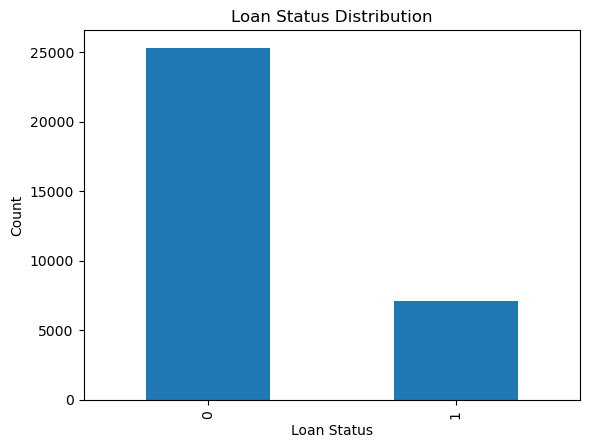

In [136]:
df["loan_status"].value_counts().plot(kind="bar")

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")

plt.show()

# Step 25: Analyze Home Ownership vs Loan Status

Compare loan default rates across different home ownership categories to identify potential risk patterns.

In [137]:
pd.crosstab(df["person_home_ownership"], df["loan_status"])

loan_status,0,1
person_home_ownership,,
MORTGAGE,11679,1687
OTHER,73,33
OWN,2371,192
RENT,11198,5176


# Step 26: Calculate Default Rate by Home Ownership

Calculate the percentage of loan defaults for each home ownership category to enable a fair comparison across groups.

In [138]:
pd.crosstab(
    df["person_home_ownership"],
    df["loan_status"],
    normalize="index"
) * 100

loan_status,0,1
person_home_ownership,,
MORTGAGE,87.378423,12.621577
OTHER,68.867925,31.132075
OWN,92.508779,7.491221
RENT,68.388909,31.611091


# Step 27: Analyze Loan Intent vs Loan Status

Calculate the percentage of loan defaults for each loan purpose to identify which types of loans are associated with higher default rates.

In [139]:
pd.crosstab(
    df["loan_intent"],
    df["loan_status"],
    normalize="index"
) * 100

loan_status,0,1
loan_intent,,
DEBTCONSOLIDATION,71.323955,28.676045
EDUCATION,82.743018,17.256982
HOMEIMPROVEMENT,73.845298,26.154702
MEDICAL,73.237339,26.762661
PERSONAL,80.112809,19.887191
VENTURE,85.138229,14.861771


# Step 28: Analyze Loan Grade vs Loan Status

Calculate the percentage of loan defaults for each loan grade to examine the relationship between credit quality and default risk.

In [140]:
pd.crosstab(
    df["loan_grade"],
    df["loan_status"],
    normalize="index"
) * 100

loan_status,0,1
loan_grade,,
A,90.039245,9.960755
B,83.676810,16.323190
C,79.241765,20.758235
D,40.950539,59.049461
E,35.514019,64.485981
F,29.460581,70.539419
G,1.562500,98.437500


# Step 29: Analyze Previous Default History vs Loan Status

Calculate the percentage of loan defaults based on the borrower's previous default history.

In [141]:
pd.crosstab(
    df["cb_person_default_on_file"],
    df["loan_status"],
    normalize="index"
) * 100

loan_status,0,1
cb_person_default_on_file,,
N,81.562969,18.437031
Y,62.139990,37.860010


# Step 30: Compare Loan-to-Income Ratio by Loan Status

Compare the loan-to-income ratio for defaulted and non-defaulted borrowers to determine whether higher loan burdens are associated with increased default risk.

In [142]:
df.groupby("loan_status")["loan_percent_income"].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
0,25321.0,0.148803,0.087245,0.00,0.08,0.13,0.20,0.83
1,7088.0,0.246858,0.132050,0.01,0.14,0.24,0.34,0.78


# Step 31: Compare Interest Rate by Loan Status

Compare interest rates between defaulted and non-defaulted borrowers to determine whether higher interest rates are associated with increased default risk.

In [143]:
df.groupby("loan_status")["loan_int_rate"].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
0,25321.0,10.492467,2.839694,5.42,7.88,10.99,12.53,22.06
1,7088.0,12.879454,3.194582,5.42,10.99,12.99,15.31,23.22


# Step 32: Compare Annual Income by Loan Status

Compare annual income between defaulted and non-defaulted borrowers to determine whether income influences loan default.

In [144]:
df.groupby("loan_status")["person_income"].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
0,25321.0,70597.359070,55311.483970,7000.0,42000.0,60000.0,84000.0,2039784.0
1,7088.0,49093.100451,36344.725503,4000.0,30000.0,41655.0,59600.0,703800.0


# Step 33: Correlation Analysis

Calculate the correlation matrix to examine relationships between numerical variables and identify features associated with loan default.

In [145]:
df.corr(numeric_only=True)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
person_age,1.000000,0.140487,0.170606,0.051646,0.010493,-0.021774,-0.041468,0.878240
person_income,0.140487,1.000000,0.155094,0.316732,-0.000959,-0.169262,-0.294766,0.122654
person_emp_length,0.170606,0.155094,1.000000,0.111896,-0.053037,-0.085967,-0.058419,0.147920
loan_amnt,0.051646,0.316732,0.111896,1.000000,0.139587,0.105601,0.572632,0.042139
loan_int_rate,0.010493,-0.000959,-0.053037,0.139587,1.000000,0.320041,0.114316,0.014961
loan_status,-0.021774,-0.169262,-0.085967,0.105601,0.320041,1.000000,0.379580,-0.016441
loan_percent_income,-0.041468,-0.294766,-0.058419,0.572632,0.114316,0.379580,1.000000,-0.031214
cb_person_cred_hist_length,0.878240,0.122654,0.147920,0.042139,0.014961,-0.016441,-0.031214,1.000000


# Step 34: Visualize the Correlation Matrix

Visualize the correlation matrix to identify relationships between numerical variables and potential predictors of loan default.

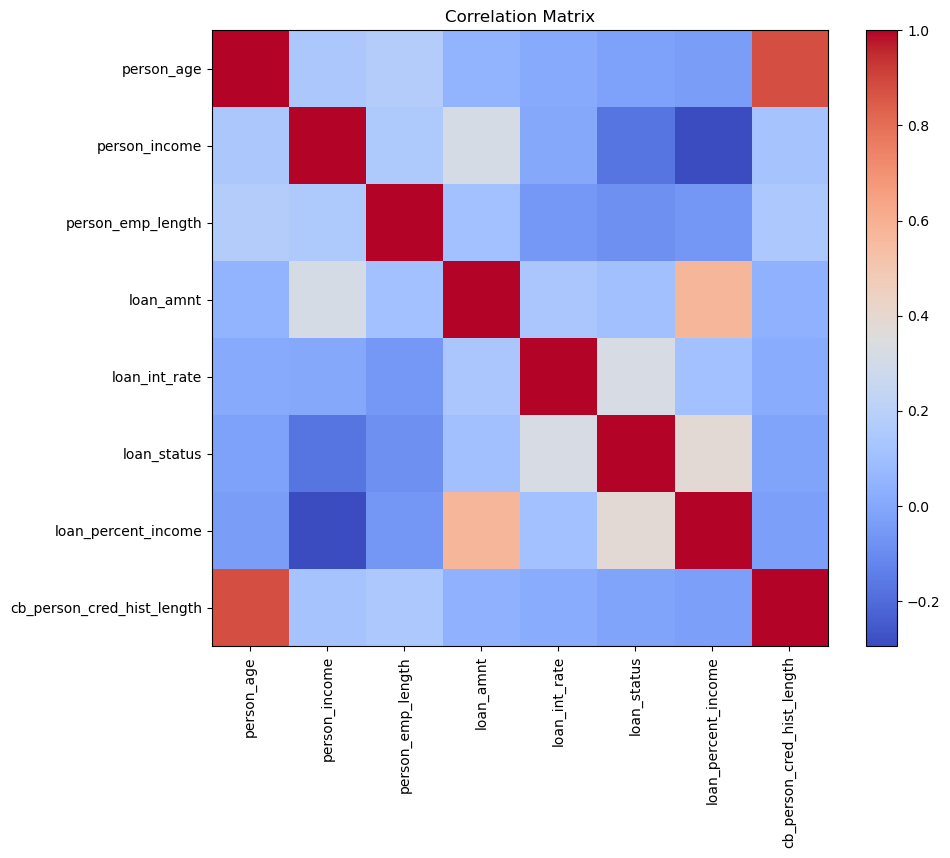

In [146]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.imshow(df.corr(numeric_only=True), cmap="coolwarm")

plt.colorbar()

plt.xticks(
    range(len(df.corr(numeric_only=True).columns)),
    df.corr(numeric_only=True).columns,
    rotation=90
)

plt.yticks(
    range(len(df.corr(numeric_only=True).columns)),
    df.corr(numeric_only=True).columns
)

plt.title("Correlation Matrix")

plt.show()

# Step 35: Separate Features and Target Variable

Separate the independent variables (features) from the target variable (`loan_status`) in preparation for building the machine learning model.

In [147]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

# Step 36: Encode Categorical Variables

Convert categorical variables into numerical values so they can be used by the machine learning model.

In [148]:
X = pd.get_dummies(X, drop_first=True)

# Step 37: Verify Encoded Features

Display the first five rows of the encoded feature set to confirm that categorical variables have been converted into numerical values.

In [149]:
X.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
1,21,9600,5.0,1000,11.14,0.10,2,False,True,False,...,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,0.57,3,False,False,False,...,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,0.53,2,False,False,True,...,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,0.55,4,False,False,True,...,True,False,False,False,True,False,False,False,False,True
5,21,9900,2.0,2500,7.14,0.25,2,False,True,False,...,False,False,True,False,False,False,False,False,False,False


# Step 38: Split the Data into Training and Testing Sets

Split the dataset into training and testing sets to evaluate the performance of the machine learning model on unseen data.

In [150]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

# Step 39: Verify the Training and Testing Sets

Display the dimensions of the training and testing datasets to confirm that the data has been split correctly.

In [151]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((25927, 22), (6482, 22), (25927,), (6482,))

# Step 40: Train the Logistic Regression Model

Train a Logistic Regression model to predict whether a borrower is likely to default on a loan.

In [152]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


# Step 41: Make Predictions

Use the trained Logistic Regression model to predict loan default on the testing dataset.

In [153]:
y_pred = model.predict(X_test)

# Step 42: Calculate Model Accuracy

Calculate the accuracy of the Logistic Regression model on the testing dataset.

In [154]:
accuracy_score(y_test, y_pred)

0.7904967602591793

# Step 43: Generate the Confusion Matrix

Generate a confusion matrix to compare the model's predicted loan status with the actual loan status.

In [155]:
confusion_matrix(y_test, y_pred)

array([[4015, 1045],
       [ 313, 1109]], dtype=int64)

# Step 44: Generate the Classification Report

Generate a classification report to evaluate the model using precision, recall, and F1-score.

In [156]:
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       0.93      0.79      0.86      5060\n           1       0.51      0.78      0.62      1422\n\n    accuracy                           0.79      6482\n   macro avg       0.72      0.79      0.74      6482\nweighted avg       0.84      0.79      0.80      6482\n'

# Step 45: Identify the Most Important Features

Examine the Logistic Regression coefficients to identify which features have the greatest influence on loan default prediction.

In [157]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

feature_importance.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
17,loan_grade_D,1.140361
18,loan_grade_E,0.826835
5,loan_percent_income,0.805531
9,person_home_ownership_RENT,0.697346
11,loan_intent_HOMEIMPROVEMENT,0.414468
19,loan_grade_F,0.319341
21,cb_person_default_on_file_Y,0.214566
4,loan_int_rate,0.208307
20,loan_grade_G,0.164571
7,person_home_ownership_OTHER,0.067145


# Step 46: Calculate Risk Scores and Risk Categories

Based on the trained logistic regression model, calculate a risk score (0-100) for each loan applicant. Then categorize each applicant into one of three risk tiers:
- Low Risk (0-30): Safe to approve
- Medium Risk (30-60): Approve with caution
- High Risk (60-100): Reject or require collateral

These risk scores will be used for all downstream business recommendations and decision-making.

In [158]:
risk_score = model.predict_proba(X)[:, 1] * 100
df["Risk Score"] = risk_score.round(2)

df["Risk Category"] = pd.cut(
    df["Risk Score"],
    bins=[0, 30, 60, 100],
    labels=["Low Risk", "Medium Risk", "High Risk"],
    include_lowest=True)

In [159]:
df["Risk Category"].value_counts()

Risk Category
Low Risk       14107
Medium Risk    10381
High Risk       7921
Name: count, dtype: int64

# Step 47: Approval Strategy by Risk Tier

Analyze the default rate for each risk tier and define specific approval decisions based on actual default patterns in the data.

In [160]:
print("APPROVAL STRATEGY BY RISK TIER\n")

for tier in ["Low Risk", "Medium Risk", "High Risk"]:
    subset = df[df["Risk Category"] == tier]
    default_rate = (subset["loan_status"] == 1).sum() / len(subset) * 100
    
    if tier == "Low Risk":
        decision = "APPROVE"
    elif tier == "Medium Risk":
        decision = "APPROVE WITH CAUTION"
    else:
        decision = "REJECT"
    
    print(f"{tier} ({len(subset):,}): {default_rate:.1f}% default → {decision}")

APPROVAL STRATEGY BY RISK TIER

Low Risk (14,107): 4.9% default → APPROVE
Medium Risk (10,381): 15.5% default → APPROVE WITH CAUTION
High Risk (7,921): 60.5% default → REJECT


# Step 48: Portfolio Impact Analysis

Calculate the financial impact of the selective approval strategy (Low + Medium Risk only) compared to approving all loans.

In [161]:
approved = df[df["Risk Category"].isin(["Low Risk", "Medium Risk"])]
rejected = df[df["Risk Category"] == "High Risk"]

total_portfolio = df["loan_amnt"].sum()
approved_volume = approved["loan_amnt"].sum()
rejected_volume = rejected["loan_amnt"].sum()

loss_if_all = (df["loan_status"] == 1).sum() / len(df) * total_portfolio
loss_if_approved = (approved["loan_status"] == 1).sum() / len(approved) * approved_volume
savings = loss_if_all - loss_if_approved

print("PORTFOLIO IMPACT\n")
print(f"Total Portfolio: ${total_portfolio:,.0f}")
print(f"Approve (Low+Medium): ${approved_volume:,.0f} ({approved_volume/total_portfolio*100:.1f}%)")
print(f"Reject (High Risk): ${rejected_volume:,.0f} ({rejected_volume/total_portfolio*100:.1f}%)")
print(f"\nExpected Loss (Approve All): ${loss_if_all:,.0f}")
print(f"Expected Loss (Low+Medium Only): ${loss_if_approved:,.0f}")
print(f"Annual Savings: ${savings:,.0f}")

PORTFOLIO IMPACT

Total Portfolio: $310,882,900
Approve (Low+Medium): $219,580,900 (70.6%)
Reject (High Risk): $91,302,000 (29.4%)

Expected Loss (Approve All): $67,991,545
Expected Loss (Low+Medium Only): $20,605,885
Annual Savings: $47,385,661


# Step 49: Business Recommendations

Based on the risk analysis of 32,409 loans totaling $310.9M, the following recommendations are made:

## Approval Strategy

**Approve Low Risk (14,107 loans | 4.9% default rate)**
- Decision: Approve all applications
- Interest Rate: Base Rate - 0.5% (incentivize best customers)
- Portfolio Volume: Significant approval rate with minimal loss

**Approve Medium Risk with Caution (10,381 loans | 15.5% default rate)**
- Decision: Approve with additional documentation and verification
- Interest Rate: Base Rate (standard pricing)
- Risk Management: Implement enhanced monitoring and early payment tracking

**Reject High Risk (7,921 loans | 60.5% default rate)**
- Decision: Reject or require substantial collateral
- Rationale: Extremely high default rate (60.5%) makes unsecured lending not viable
- Exception: Only consider if collateral covers 150%+ of loan amount

## Financial Impact

By implementing selective approval (Low + Medium Risk only):
- Approval Rate: 70.6% of portfolio ($219.6M)
- Rejection Rate: 29.4% of portfolio ($91.3M)
- Expected Annual Loss Reduction: **$47.4M**
- Default Rate Improvement: From 21.8% to 9.4%

## Implementation Priority

1. Immediately deploy risk scoring for all new applications
2. Update underwriting approval matrix by risk tier
3. Adjust interest rate pricing structure within 30 days
4. Monitor actual vs predicted defaults monthly
5. Retrain model quarterly with new default data

# Step 50: Export Data for Tableau

Export cleaned data and risk analysis results in CSV format for Tableau dashboard creation. These files will be used to build visualizations for business stakeholders.

In [162]:
df.to_csv("credit_risk_clean.csv", index=False)